# Capitolo 6 (parte 1) — Serie temporali con LSTM
Temperatura minima giornaliera a Melbourne, 1981–1990.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import numpy as np
import matplotlib.pyplot as plt

import torch, pandas as pd, urllib.request, os
from torch import nn
fissa_seme(42)

3650
count    3650.0
mean       11.2
std         4.1
min         0.0
25%         8.3
50%        11.0
75%        14.0
max        26.3
Name: Temp, dtype: float64


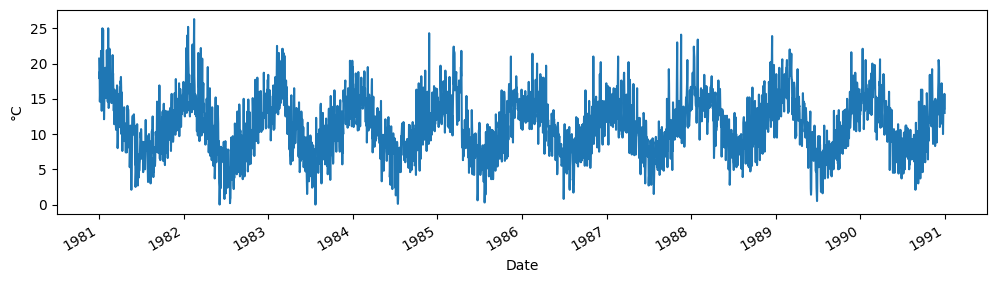

In [2]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
if not os.path.exists("daily-min-temperatures.csv"):
    urllib.request.urlretrieve(URL, "daily-min-temperatures.csv")
df = pd.read_csv("daily-min-temperatures.csv", parse_dates=["Date"])
print(len(df)); print(df["Temp"].describe().round(1))
df.plot(x="Date", y="Temp", figsize=(12, 3), legend=False); plt.ylabel("°C"); plt.show()

## Finestre — divisione nel tempo, normalizzazione con il training

In [3]:
serie = df["Temp"].values.astype(np.float32)
n_train = 365 * 8
tr, te = serie[:n_train], serie[n_train:]
media, dev = tr.mean(), tr.std()
tr_n, te_n = (tr - media) / dev, (te - media) / dev

F = 30
def finestre(s):
    X = np.stack([s[i:i+F] for i in range(len(s) - F)])
    y = s[F:]
    return torch.from_numpy(X).unsqueeze(-1), torch.from_numpy(y)

X_tr, y_tr = finestre(tr_n)
X_te, y_te = finestre(te_n)
print(X_tr.shape, X_te.shape)

torch.Size([2890, 30, 1]) torch.Size([700, 30, 1])


## La linea di base

In [4]:
mae = lambda a, b: float(np.mean(np.abs(a - b)))
print("Persistenza:   ", round(mae(te[F:], te[F-1:-1]), 3), "°C")
print("Media mobile 7:", round(mae(te[F:], np.array([te[i-7:i].mean() for i in range(F, len(te))])), 3), "°C")

Persistenza:    1.951 °C
Media mobile 7: 2.031 °C


## Il modello

In [5]:
class LSTMPrevisione(nn.Module):
    def __init__(self, nascosti=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=nascosti, batch_first=True)
        self.fc = nn.Linear(nascosti, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)

class MLPFinestra(nn.Module):
    def __init__(self):
        super().__init__()
        self.rete = nn.Sequential(nn.Flatten(), nn.Linear(F, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        return self.rete(x).squeeze(1)

def addestra(m, epoche=30, lr=1e-3):
    perdita_fn = nn.MSELoss(); opt = torch.optim.Adam(m.parameters(), lr=lr)
    for e in range(epoche):
        m.train(); perm = torch.randperm(len(X_tr))
        for i in range(0, len(X_tr), 64):
            idx = perm[i:i+64]
            opt.zero_grad(); perdita_fn(m(X_tr[idx]), y_tr[idx]).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            prev = m(X_te).numpy() * dev + media
        if e % 5 == 4 or e == 0:
            print(f"Epoca {e+1:2d}: MAE test {mae(te[F:], prev):.3f} °C")
    return prev

In [6]:
fissa_seme(42)
lstm = LSTMPrevisione()
print("Parametri:", sum(p.numel() for p in lstm.parameters()))
prev = addestra(lstm)

Parametri: 4513


Epoca  1: MAE test 2.007 °C


Epoca  5: MAE test 1.871 °C


Epoca 10: MAE test 1.776 °C


Epoca 15: MAE test 1.740 °C


Epoca 20: MAE test 1.738 °C


Epoca 25: MAE test 1.733 °C


Epoca 30: MAE test 1.726 °C


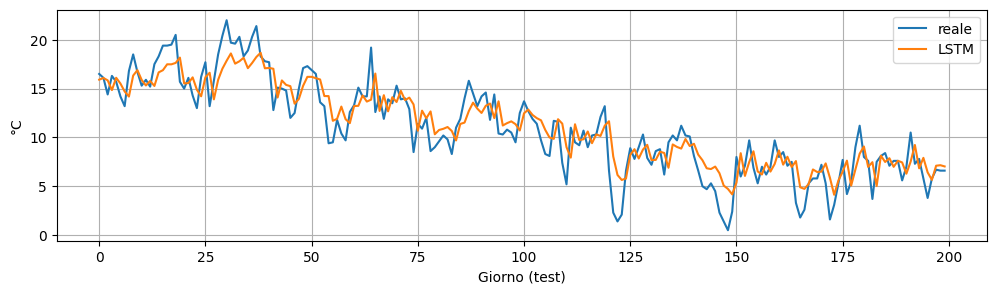

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(te[F:F+200], label="reale"); plt.plot(prev[:200], label="LSTM")
plt.xlabel("Giorno (test)"); plt.ylabel("°C"); plt.legend(); plt.grid(True); plt.show()

In [8]:
fissa_seme(42)
print("MLP sulle stesse finestre:")
prev_mlp = addestra(MLPFinestra())

MLP sulle stesse finestre:
Epoca  1: MAE test 2.050 °C


Epoca  5: MAE test 1.779 °C


Epoca 10: MAE test 1.740 °C


Epoca 15: MAE test 1.747 °C


Epoca 20: MAE test 1.776 °C


Epoca 25: MAE test 1.747 °C


Epoca 30: MAE test 1.764 °C


## Previsione ricorsiva a 30 giorni

[15.9 15.7 15.7 15.6 15.6 15.6 15.5 15.5 15.5 15.5 15.4 15.4 15.4 15.4
 15.4 15.4 15.3 15.3 15.3 15.3 15.3 15.3 15.3 15.3 15.3 15.2 15.2 15.2
 15.2 15.2]


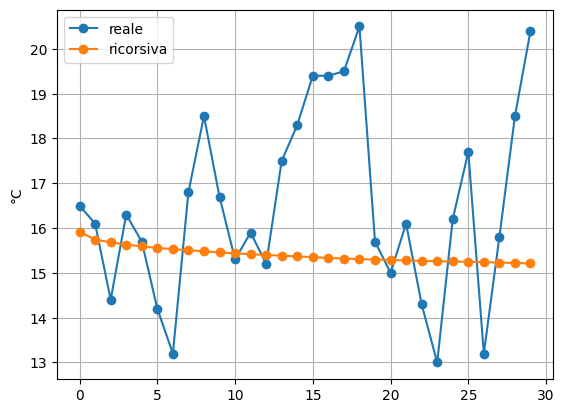

In [9]:
lstm.eval(); x = X_te[0:1].clone(); ricorsiva = []
with torch.no_grad():
    for k in range(30):
        y = lstm(x); ricorsiva.append(y.item())
        x = torch.cat([x[:, 1:, :], y.view(1, 1, 1)], dim=1)
ricorsiva = np.array(ricorsiva) * dev + media
print(np.round(ricorsiva, 1))
plt.plot(te[F:F+30], marker="o", label="reale"); plt.plot(ricorsiva, marker="o", label="ricorsiva")
plt.legend(); plt.grid(True); plt.ylabel("°C"); plt.show()